In [31]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
X,y_true = make_blobs(n_samples=500,centers=3,cluster_std=4,random_state=42)

In [15]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [17]:
df

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [20]:
inertia = []
K_range = range(1,11)

In [21]:
for k in K_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [22]:
inertia

[1000.0000000000001,
 528.8064432605652,
 294.4377068678189,
 250.45524696534466,
 216.8811065698262,
 185.27440675195913,
 156.70879996290458,
 135.62603453115256,
 129.10396348239817,
 119.94101297104999]

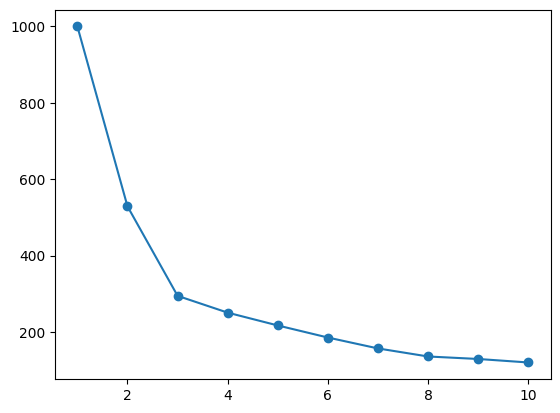

In [23]:
plt.plot(K_range,inertia,marker='o')

In [24]:
kmeans_final = KMeans(n_clusters=6,random_state=42)

In [25]:
cluster_label = kmeans_final.fit_predict(X_scaled)

In [26]:
df['cluster'] = cluster_label

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

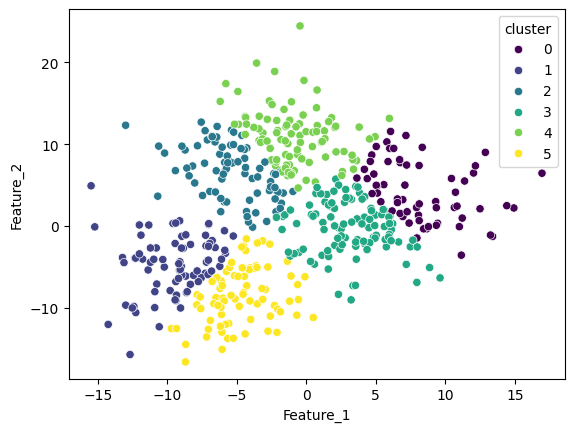

In [27]:
sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['cluster'],
    palette='viridis'
)

In [28]:
from sklearn.datasets import make_moons

In [29]:
X,y_true = make_moons(n_samples=500,noise=0.05,random_state=42)

In [32]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [39]:
kmeans_final = KMeans(n_clusters=2,random_state=42)
kmeans_label = kmeans_final.fit_predict(X_scaled)

In [40]:
df['kmeans_cluster'] = kmeans_label

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

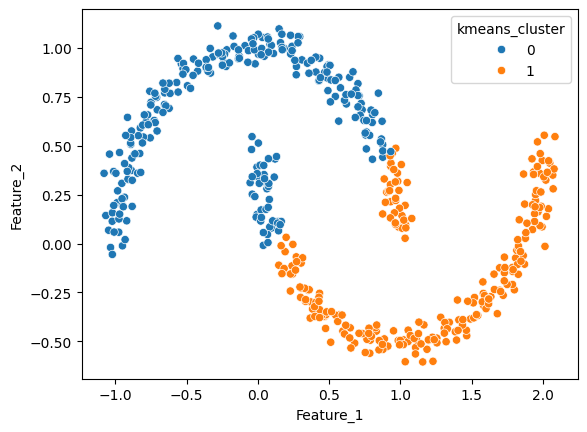

In [41]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')

In [42]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

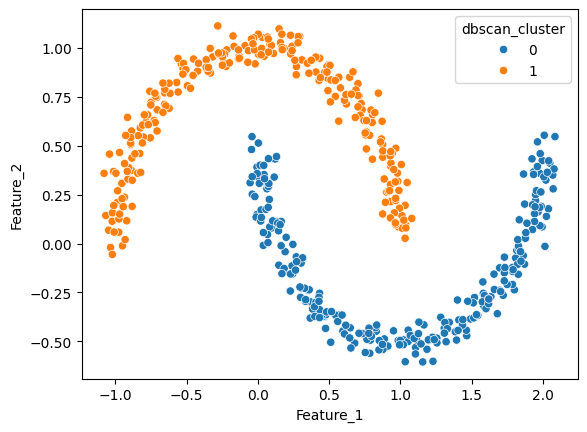

In [43]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')